# Exercício de Probabilidade e Amostragem

In [240]:
import pandas as pd
import numpy as np
import scipy.stats as stats
from scipy.stats import binom, norm

import matplotlib.pyplot as plt
import seaborn as sns

In [241]:
df = pd.read_csv('populacao_brasileira.csv')

In [242]:
df.head()

,Unnamed: 0,estado,idade,escolaridade,nível de proficiência em inglês,renda,sexo
0,0,MA,56,Fundamental,Intermediário,4006.29,F
1,1,BA,46,Superior,Básico,2423.11,M
2,2,AM,32,Fundamental,Intermediário,3835.69,M
3,3,CE,60,Superior,Básico,1870.29,M
4,4,SE,25,Fundamental,Avançado,3529.80,M


In [243]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       1000 non-null   int64  
 1   estado                           1000 non-null   object 
 2   idade                            1000 non-null   int64  
 3   escolaridade                     1000 non-null   object 
 4   nível de proficiência em inglês  1000 non-null   object 
 5   renda                            1000 non-null   float64
 6   sexo                             1000 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


1. Considere pessoas fluentes em inglês, qual a probabilidade complementar? Ou seja, qual a probabilidade de escolhermos uma pessoa aleatória e ela não ser fluente em inglês. Considere fluente quem tem o nível avançado

In [244]:
df['nível de proficiência em inglês'].value_counts()

nível de proficiência em inglês
Avançado         344
Intermediário    329
Básico           327
Name: count, dtype: int64

In [245]:
total = df['nível de proficiência em inglês'].value_counts().sum()

fluentes = df[df['nível de proficiência em inglês'] == 'Avançado'].value_counts().sum()

nao_fluentes = total - fluentes

p = (nao_fluentes/total).round(4)

print(f'A probabilidade de escolhermos uma pessoa aleatória e ela não ser fluente em inglês é de: {p:.2%}')

A probabilidade de escolhermos uma pessoa aleatória e ela não ser fluente em inglês é de: 65.60%


2. Se uma pessoa escolhida aleatoriamente for de Alagoas ou do Pará, qual é a probabilidade de ela ter uma renda superior a 5 mil reais?

In [246]:
df[(df['renda'] > 5000) & ((df['estado'] == 'AL') | (df['estado'] == 'PA'))]

,Unnamed: 0,estado,idade,escolaridade,nível de proficiência em inglês,renda,sexo
116,116,PA,29,Fundamental,Intermediário,5573.36,F
371,371,PA,57,Fundamental,Intermediário,5163.25,M
619,619,AL,62,Fundamental,Básico,5252.44,M
691,691,AL,53,Superior,Intermediário,5210.52,F


In [247]:
al_pa = df[(df['estado'] == 'AL') | (df['estado'] == 'PA')]

total_al_pa = len(al_pa['estado'])

renda_maior_5000 = len(al_pa[al_pa['renda'] > 5000])

p = (renda_maior_5000/total_al_pa) # Usando o len() não consegio colocar o round()

print(f'Se uma pessoa escolhida aleatoriamente for de Alagoas ou do Pará, a probabilidade de ela ter uma renda superior a 5 mil reais é de: {p:.4f}')

Se uma pessoa escolhida aleatoriamente for de Alagoas ou do Pará, a probabilidade de ela ter uma renda superior a 5 mil reais é de: 0.0506


3. Descubra a probabilidade de uma pessoa ter ensino superior completo no estado do Amazonas. Qual a probabilidade da quinta pessoa que você conversar, que é amazonense, ter ensino superior completo?

In [248]:
pessoas_amazonas = df[df['estado']=='AM']
p_superior = pessoas_amazonas[(pessoas_amazonas['escolaridade']=='Superior')|(pessoas_amazonas['escolaridade']=='Pós-graduação')]

tota_am = pessoas_amazonas.shape[0]

prop_am = len(p_superior)/tota_am

prob_geo_5_pessoas = stats.geom.pmf(k=5,p=prop_am)

print(f'A probabilidade da quinta pessoa que você conversar, que é amazonense, ter ensino superior completo é:..... {prob_geo_5_pessoas:.2%}')

A probabilidade da quinta pessoa que você conversar, que é amazonense, ter ensino superior completo é:..... 2.21%


4. Considerando a renda das pessoas do nosso conjunto, podemos dizer que a renda de uma pessoa brasileira está na sua maioria em que faixa (faça faixa de 1.500 reais)? Qual é a sua função densidade de probabilidade?

A faixa predominante de renda é entre 3000 e 4500 Reais.



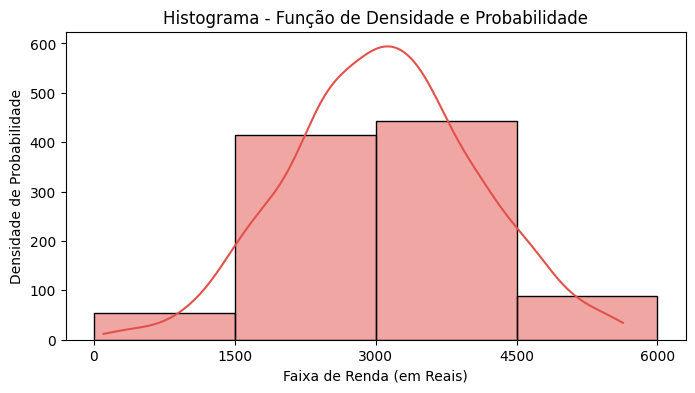

CPU times: total: 188 ms
Wall time: 188 ms


In [249]:
%%time
intervalo = 1500
bins = range(0, int(df['renda'].max()) + intervalo, intervalo)

frequencias, _ = np.histogram(df['renda'], bins=bins)

faixa_predominante = bins[np.argmax(frequencias)]
faixa_predominante_prox = bins[np.argmax(frequencias) + 1]
print(f'A faixa predominante de renda é entre {faixa_predominante} e {faixa_predominante_prox} Reais.\n')

sns.set_palette("Spectral")
plt.figure(figsize=(8, 4))
sns.histplot(df['renda'], bins=bins, kde=True)
plt.title('Histograma - Função de Densidade e Probabilidade')
plt.xlabel('Faixa de Renda (em Reais)')
plt.ylabel('Densidade de Probabilidade')
plt.xticks(bins)
plt.show()

5. Calcule a média e a variância da renda da amostra. Depois faça a distribuição normal, inclua o gráfico.

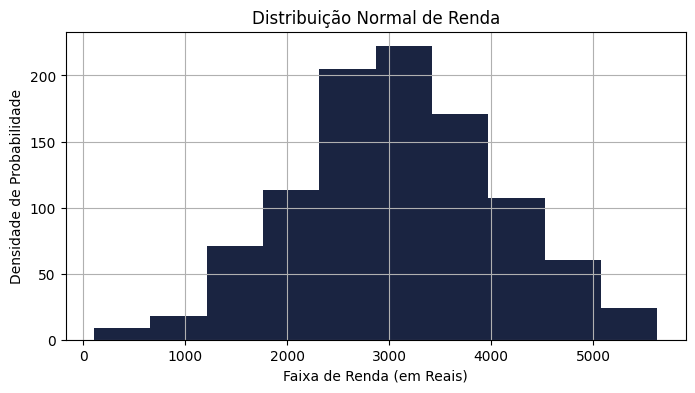


Média da Renda: 3082.54
Variância da Renda: 993156.23

CPU times: total: 141 ms
Wall time: 149 ms


In [250]:
%%time

media = df['renda'].mean()
variancia = df['renda'].var()

sns.set_palette("cubehelix")
plt.figure(figsize=(8, 4))
plt.hist(df['renda'],bins = 10)
plt.title('Distribuição Normal de Renda')
plt.xlabel('Faixa de Renda (em Reais)')
plt.ylabel('Densidade de Probabilidade')
plt.xticks()
plt.grid()
plt.show()

print(f"\nMédia da Renda: {media:.2f}")
print(f"Variância da Renda: {variancia:.2f}\n")

6. Primeiro considere a probabilidade encontrada no nosso conjunto de pessoas com escolaridade de pós-graduação. Considerando a amostra de população brasileira com 1 milhão de habitantes, qual a probabilidade de encontrarmos 243 mil pessoas com pós-graduação?

In [251]:
# binomial
total_conjunto_escolaridade = len(df['escolaridade'])

pessoas_pos = len(df[df['escolaridade']=='Pós-graduação'])

p_pos = pessoas_pos/total_conjunto_escolaridade

print(f'Pessoas com probabilidade de ter pós-graduação, dentro do conjunto: {p_pos:.2%}')

Pessoas com probabilidade de ter pós-graduação, dentro do conjunto: 25.30%


In [252]:
n = 1000000
k = 243000

prop_pos = stats.binom.pmf(k,n,p_pos) 

print(f'A probabilidade de encontrar 243 mil pessoas é de: {prop_pos}')

A probabilidade de encontrar 243 mil pessoas é de: 1.1104854289794913e-119


7. Somando as densidades nós temos a função de densidade acumulada. Considerando a coluna ‘Escolaridade’ faça a função de densidade acumulada discreta para cada nível de escolaridade.

In [253]:
# frequencia
escolaridade_count = df['escolaridade'].value_counts()

# frequencia relativa
freq_rel = escolaridade_count / len(df)

# densidade acumulada
dens_acumulativa = freq_rel.cumsum()
dens_acumulativa

escolaridade
Fundamental      0.266
Pós-graduação    0.519
Superior         0.762
Médio            1.000
Name: count, dtype: float64

8. Qual a margem de erro amostral da proporção populacional considerando a proporção de pessoas com nível de inglês intermediário?

In [254]:
proporcao_inter = (df['nível de proficiência em inglês'] == 'Intermediário').mean()

# Número de observações
n = len(df)

# Valor crítico z para intervalo de confiança de 95%
z = stats.norm.ppf(0.975)  # 95% de confiança

# Margem de erro
margem_erro = z * np.sqrt((proporcao_inter * (1 - proporcao_inter)) / n)

# Resultados
print(f"Proporção de pessoas com nível de inglês intermediário: {proporcao_inter:.2%}")
print(f"Margem de erro amostral: {margem_erro:.4f}")

Proporção de pessoas com nível de inglês intermediário: 32.90%
Margem de erro amostral: 0.0291


9. Calcula a renda da população. Qual a probabilidade de encontrar 60 pessoas com uma renda mil reais superior à média?

In [255]:
media_renda = df['renda'].mean()
mil_superior = media_renda + 1000
proporcao_superior = (df['renda'] >= mil_superior).mean()

n = len(df)
k = 60

prob = stats.binom.pmf(k, n, proporcao_superior)
print(f'A probabilidade de encontrar 60 pessoas com uma renda mil reais superior à média é de: {prob:.2%}')

A probabilidade de encontrar 60 pessoas com uma renda mil reais superior à média é de: 0.00%


10.  Qual a probabilidade de escolhermos alguém do Sudeste que seja homem, com ensino fundamental e com renda maior que 2 mil reais por mês?

In [256]:
# com ensino fundamental significa todos, então não preciso filtrar essa parte.

sudeste_homens = df[
    (df['estado'].isin(['SP', 'RJ', 'MG', 'ES'])) &
    (df['sexo'] == 'M') &
    (df['renda'] > 2000)
]

n = sudeste_homens.shape[0]
total_pessoas = df.shape[0]
prob = n / total_pessoas

print(f"A probabilidade de escolhermos alguém do Sudeste que seja homem,\
 com ensino fundamental e com renda maior que 2 mil reais por mês é de: {prob:.2%}")

A probabilidade de escolhermos alguém do Sudeste que seja homem, com ensino fundamental e com renda maior que 2 mil reais por mês é de: 6.80%
